In [1]:
import pandas as pd
import numpy as np
import os
import sys

import tsfel

from sklearn.preprocessing import StandardScaler

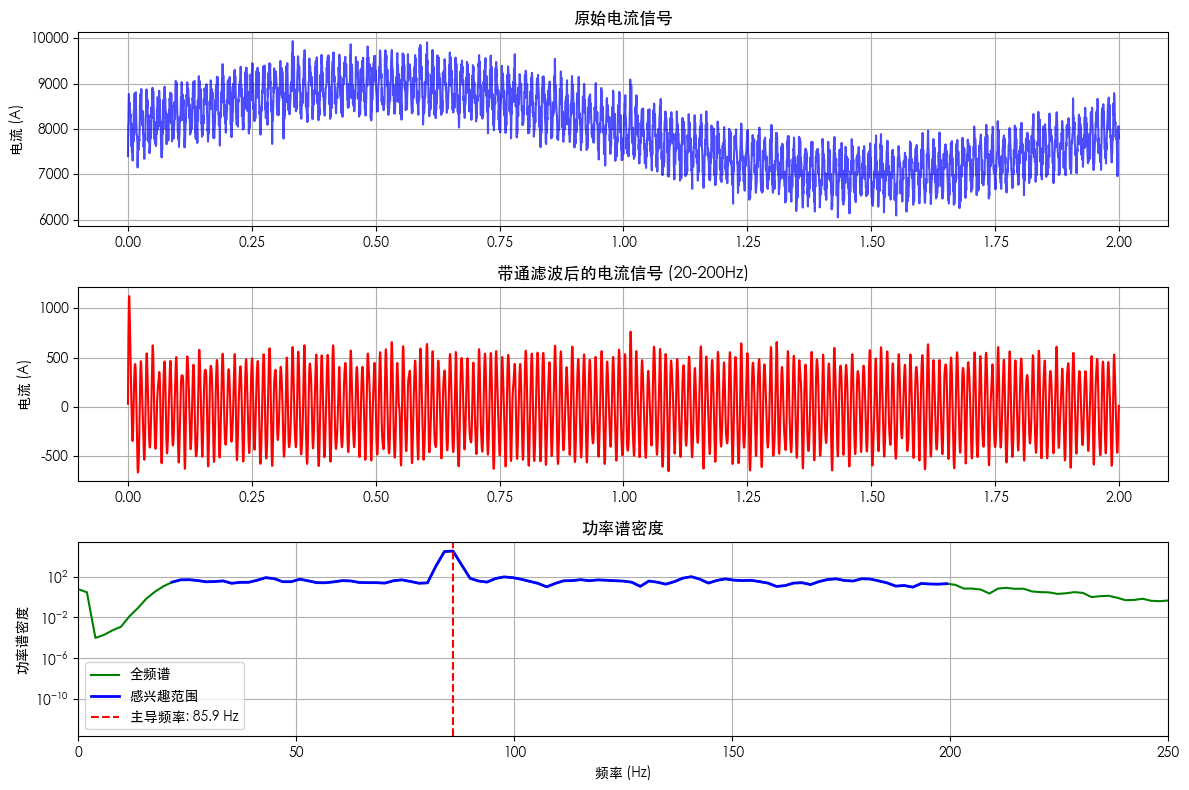

过梁爆破主导频率: 85.9 Hz
该频率的相对功率: 3.14e+04


In [7]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
# 设置字体为黑体，解决中文显示问题
plt.rcParams['font.sans-serif'] = ['STHeiti'] # 替换为 macOS 自带的中文字体
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题



def calculate_explosion_freq_psd_with_plot(time, current, lowcut=20, highcut=200):
    """
    带可视化的过梁爆破频率计算
    """
    # 计算采样率
    sampling_rate = 1 / (time[1] - time[0])
    
    # 带通滤波
    nyquist = 0.5 * sampling_rate
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(4, [low, high], btype='band')
    filtered_current = signal.filtfilt(b, a, current)
    
    # 计算功率谱密度
    freqs, psd = signal.welch(filtered_current, sampling_rate, nperseg=1024)
    
    # 寻找主导频率
    freq_mask = (freqs >= lowcut) & (freqs <= highcut)
    interested_freqs = freqs[freq_mask]
    interested_psd = psd[freq_mask]
    
    if len(interested_psd) == 0:
        return None
        
    dominant_idx = np.argmax(interested_psd)
    dominant_freq = interested_freqs[dominant_idx]
    dominant_power = interested_psd[dominant_idx]
    
    # 可视化
    plt.figure(figsize=(12, 8))
    
    # 原始信号
    plt.subplot(3, 1, 1)
    plt.plot(time, current, 'b-', alpha=0.7)
    plt.title('原始电流信号')
    plt.ylabel('电流 (A)')
    plt.grid(True)
    
    # 滤波后信号
    plt.subplot(3, 1, 2)
    plt.plot(time, filtered_current, 'r-')
    plt.title('带通滤波后的电流信号 (20-200Hz)')
    plt.ylabel('电流 (A)')
    plt.grid(True)
    
    # 功率谱密度
    plt.subplot(3, 1, 3)
    plt.semilogy(freqs, psd, 'g-', label='全频谱')
    plt.semilogy(interested_freqs, interested_psd, 'b-', linewidth=2, label='感兴趣范围')
    plt.axvline(dominant_freq, color='red', linestyle='--', 
                label=f'主导频率: {dominant_freq:.1f} Hz')
    plt.title('功率谱密度')
    plt.xlabel('频率 (Hz)')
    plt.ylabel('功率谱密度')
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 250)
    
    plt.tight_layout()
    plt.show()
    
    print(f"过梁爆破主导频率: {dominant_freq:.1f} Hz")
    print(f"该频率的相对功率: {dominant_power:.2e}")
    
    return dominant_freq

# 测试
if __name__ == "__main__":
    # 生成测试数据
    t = np.linspace(0, 2, 4000)  # 2秒，2000Hz采样
    current = (8000 + 1000 * np.sin(2*np.pi*0.5*t) +  # 基础电流
               500 * np.sin(2*np.pi*85*t) +           # 85Hz爆破频率
               200 * np.random.normal(0, 1, len(t)))  # 噪声
    
    freq = calculate_explosion_freq_psd_with_plot(t, current)

Generating STFT time-frequency plot...


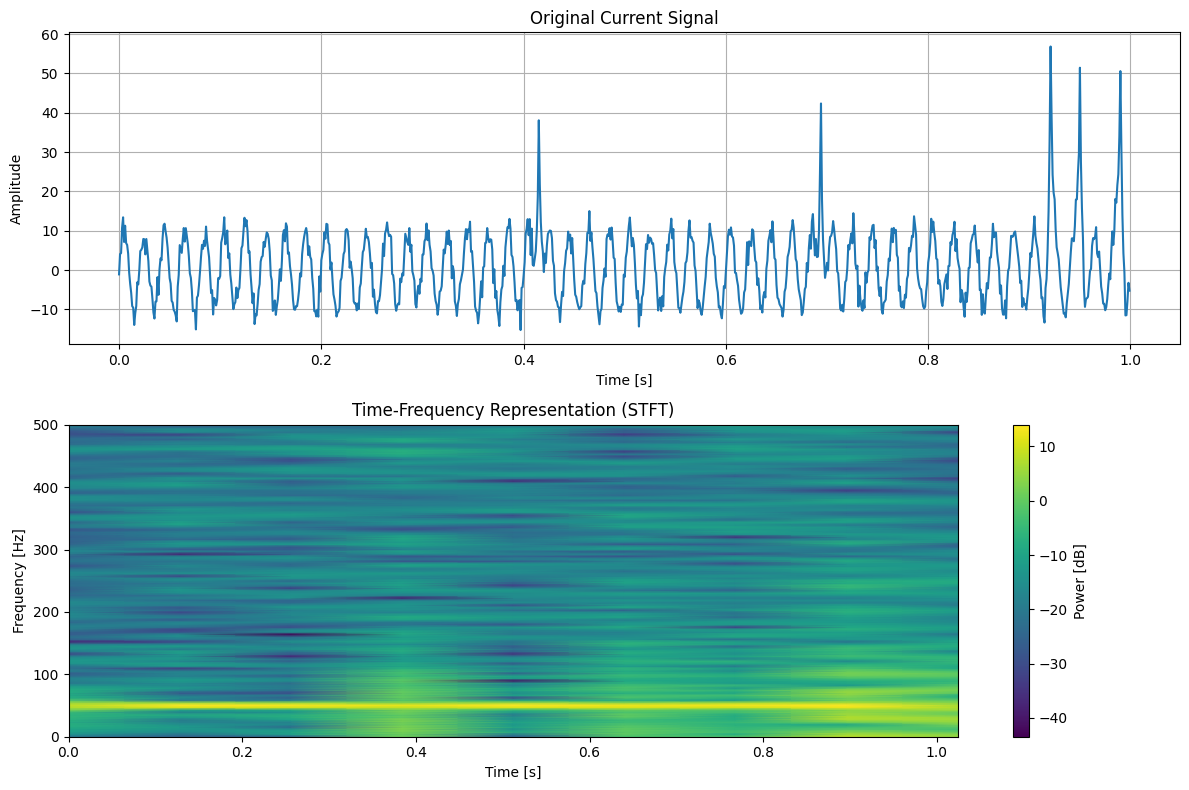

Generating CWT time-frequency plot...


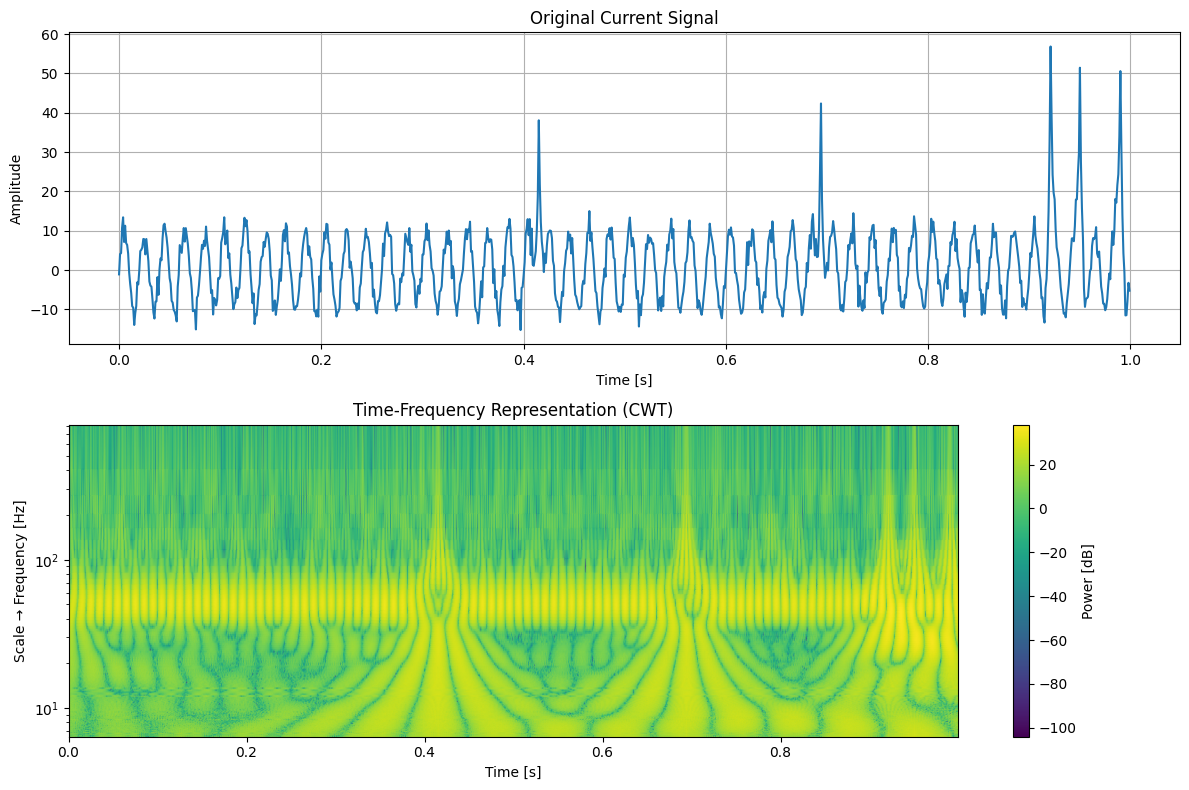

STFT power matrix shape: (129, 9)
CWT power matrix shape: (127, 1000)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pywt

class TimeFrequencyConverter:
    def __init__(self, sampling_rate=1000):
        self.sampling_rate = sampling_rate
    
    def stft_transform(self, data, nperseg=256, noverlap=None):
        """
        使用STFT生成时频图
        """
        if noverlap is None:
            noverlap = nperseg // 2
            
        f, t, Zxx = signal.stft(data, 
                               fs=self.sampling_rate,
                               nperseg=nperseg,
                               noverlap=noverlap,
                               window='hann')
        
        # 计算功率谱密度
        power = np.abs(Zxx) ** 2
        
        return f, t, power
    
    def cwt_transform(self, data, scales=None, wavelet='morl'):
        """
        使用连续小波变换生成时频图
        """
        if scales is None:
            # 自动生成尺度范围，对应频率大约从1Hz到采样率/2
            scales = np.arange(1, 128)
            
        coefficients, frequencies = pywt.cwt(data, scales, wavelet, 
                                           1.0 / self.sampling_rate)
        
        # 计算小波系数幅度
        power = np.abs(coefficients) ** 2
        
        t = np.arange(len(data)) / self.sampling_rate
        
        return frequencies, t, power
    
    def plot_time_frequency(self, data, method='stft', figsize=(12, 8)):
        """
        绘制时频图
        """
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize)
        
        # 绘制原始信号
        t = np.arange(len(data)) / self.sampling_rate
        ax1.plot(t, data)
        ax1.set_title('Original Current Signal')
        ax1.set_xlabel('Time [s]')
        ax1.set_ylabel('Amplitude')
        ax1.grid(True)
        
        # 生成并绘制时频图
        if method.lower() == 'stft':
            f, t_tf, power = self.stft_transform(data)
            im = ax2.pcolormesh(t_tf, f, 10 * np.log10(power), 
                              shading='gouraud', cmap='viridis')
            ax2.set_ylabel('Frequency [Hz]')
            
        elif method.lower() == 'cwt':
            f, t_tf, power = self.cwt_transform(data)
            im = ax2.pcolormesh(t_tf, f, 10 * np.log10(power), 
                              shading='gouraud', cmap='viridis')
            ax2.set_ylabel('Scale → Frequency [Hz]')
            ax2.set_yscale('log')
        
        ax2.set_xlabel('Time [s]')
        ax2.set_title(f'Time-Frequency Representation ({method.upper()})')
        
        plt.colorbar(im, ax=ax2, label='Power [dB]')
        plt.tight_layout()
        plt.show()
        
        return fig

def create_sample_data(duration=1.0, sampling_rate=1000):
    """
    创建包含爆破电流的样本数据
    """
    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    
    # 基础信号 - 50Hz工频
    base_signal = 10 * np.sin(2 * np.pi * 50 * t)
    
    # 添加随机爆破电流
    burst_signal = np.zeros_like(t)
    num_bursts = 5
    burst_indices = np.random.choice(len(t), num_bursts, replace=False)
    
    for idx in burst_indices:
        # 创建爆破脉冲
        burst_width = 10  # 样本点
        start = max(0, idx - burst_width // 2)
        end = min(len(t), idx + burst_width // 2)
        burst_signal[start:end] = 50 * np.exp(-np.abs(np.arange(start-idx, end-idx)) / 2)
    
    # 添加噪声
    noise = 2 * np.random.normal(size=len(t))
    
    return t, base_signal + burst_signal + noise

# 使用示例
if __name__ == "__main__":
    # 创建样本数据
    t, current_data = create_sample_data()
    
    # 初始化转换器
    converter = TimeFrequencyConverter(sampling_rate=1000)
    
    # 方法1: 使用STFT
    print("Generating STFT time-frequency plot...")
    converter.plot_time_frequency(current_data, method='stft')
    
    # 方法2: 使用CWT
    print("Generating CWT time-frequency plot...")
    converter.plot_time_frequency(current_data, method='cwt')
    
    # 单独获取时频数据（用于后续CNN训练）
    f_stft, t_stft, power_stft = converter.stft_transform(current_data)
    f_cwt, t_cwt, power_cwt = converter.cwt_transform(current_data)
    
    print(f"STFT power matrix shape: {power_stft.shape}")
    print(f"CWT power matrix shape: {power_cwt.shape}")